## オブジェクト指向

In [14]:
import random
import matplotlib.pyplot as plt

class RandomWoker:
    def __init__(self, speed = 1.0):
        self.position = 0.0 # 現在地
        self.speed = speed # ランダムウォークする移動量
        self.trajectory = [self.position] # ランダムウォークの軌跡

    def walk(self):
        # ランダムに移動するロジック（1 or -1）
        n = random.choice([-1, 1])
        # 移動
        self.position += n * self.speed
        # 軌跡に現在地を追加
        self.trajectory.append(self.position)

    def plot_trajectory(self):
        # ランダムウォークした軌跡をグラフ化する
        plt.figure(figsize=(6, 4))
        plt.plot(self.trajectory, marker='o')
        plt.title(f'Random Walk Trajectory (speed = {self.speed})', fontsize = 14)
        plt.xlabel('Step', fontsize = 12)
        plt.ylabel('Position', fontsize = 12)
        plt.show()


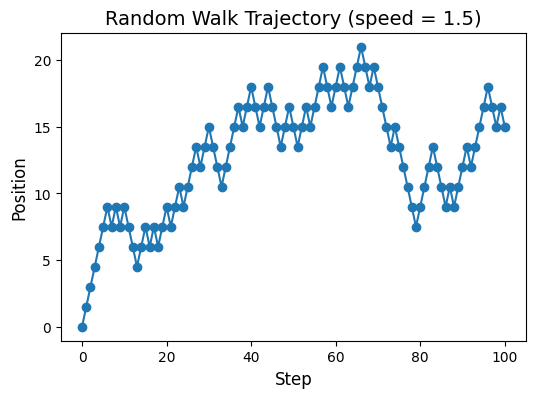

In [15]:
speed = 1.5
rw = RandomWoker(speed)
# ランダムウォークを100ステップ行う
for _ in range(100):
    rw.walk()
# ランダムウォークの軌跡をプロットする
rw.plot_trajectory()

## 格子上での進化ゲーム

In [16]:
class Agent:
    def __init__(self):
        # 協力か非協力かをランダムに決定
        self.strategy = random.choice(['C', 'D']) # C: 協力, D: 非協力
        # 更新後に使う戦略
        self.next_strategy = None
        # 世代ごとのリセット
        self.reset()

    def reset(self) -> None:
        self.payoff = 0 # 利得の初期化

    def get_payoff(self, p: float) -> None:
        self.payoff += p

    def find_next_strategy(self, neighbors: list[list]) -> None:
        """
        """
        list_with_me = neighbors + [self]
        # 同じ利得がいる場合に備えて、参照額をシャッフル
        random.shuffle(list_with_me)
        # 最も利得が高いエージェントを見つける
        max_agent = list_with_me[0] # 初期値
        for i in range(1, len(list_with_me)):
            a = list_with_me[i]
            if a.payoff > max_agent.payoff:
                max_agent = a
        # 最も利得が高いエージェントの戦略をメモ
        self.next_strategy = max_agent.strategy

    def update_strategy(self) -> None:
        self.strategy = self.next_strategy

In [17]:
L = 50 # 格子の一辺の長さ

# 利得行列
pmatrix = {
    ('C', 'C'): 5, # 相互協力
    ('C', 'D'): 0, # 自分が協力, 相手が非協力
    ('D', 'C'): 6, # 自分が非協力, 相手が協力
    ('D', 'D'): 1  # 相互非協力
}

agent_list = []

# エージェントの初期化
def initialize() -> None:
    global agent_list, L
    # 50x50の格子にエージェントを配置
    agent_list = [[Agent() for _ in range(L)] for _ in range(L)]

def reset() -> None:
    global agent_list
    for i in agent_list:
        for a in i:
            a.reset()

# 全ての隣り合ったエージェント間でゲームを実施する
def play_game() -> None:
    global agent_list, pmatrix

    # それぞれのエージェントの処理
    for i, l in enumerate(agent_list):
        for j, focal in enumerate(l):


            # 左隣のエージェント
            opp1 = agent_list[i][j-1]

            ## 互いの戦略からゲームの利得を得る
            p_focal = pmatrix[(focal.strategy, opp1.strategy)]
            p_opp = pmatrix[(opp1.strategy, focal.strategy)]

            # focal へ利得を追加
            focal.get_payoff(p_focal)
            # opp1 へ利得を追加
            opp1.get_payoff(p_opp)

            # 上隣のエージェント
            opp2 = agent_list[i-1][j]

            ## 互いの戦略からゲームの利得を得る
            p_focal = pmatrix[(focal.strategy, opp2.strategy)]
            p_opp = pmatrix[(opp2.strategy, focal.strategy)]

            # focal へ利得を追加
            focal.get_payoff(p_focal)
            # opp2 へ利得を追加
            opp2.get_payoff(p_opp)

# 全エージェントの戦略を同期的に更新させる
def update_strategy() -> None:
    global L, agent_list

    # それぞれのエージェントの処理
    for i, l in enumerate(agent_list):
        for j, focal in enumerate(l):


            neighbors = [
                agent_list[i-1][j], # 上
                agent_list[i][j-1], # 左
                agent_list[i+1-L][j], # 下
                agent_list[i][j+1-L] # 右
            ]

            # 隣人の戦略の中で最も利得の高い戦略を見つける
            focal.find_next_strategy(neighbors)

    # 全エージェントの戦略を更新する
    for l in agent_list:
        for a in l:
            a.update_strategy()

# 協力者割合を計算して返す
def calc_C_frequency() -> float:
    global agent_list

    # 協力者人数
    nC = 0
    for l in agent_list:
        for focal in l:
            if focal.strategy == 'C':
                nC += 1

    # エージェント総数（L×L）で割って協力者割合を返す
    return nC / (L * L)

def simulate(Tmax = 100) -> None:

    initialize() # エージェントの初期化

    # 協力者割合を記録
    fC_list = [calc_C_frequency()]

    # 世代を Tmax 回繰り返す
    for i in range(Tmax):
        reset() # エージェントの利得をリセット
        play_game() # ゲームを実施
        update_strategy() # 戦略を更新

        fC_list.append(calc_C_frequency()) # 協力者割合を記録

        # 進捗確認用のバーを表示
        t = Tmax / 10
        if (i+1)%t == 0:
            print("*"*int((i+1)/t) + 
                "_"*(10-int((i+1)/t)), 
                f"{int((i+1)/Tmax*100):3d}%",  
                end='\r' if (i+1)<Tmax else '\n')
            
    # 協力者割合の推移をグラフ化する
    plt.ylim(0,1)
    plt.xlabel('generation', fontsize=12)
    plt.ylabel('cooperation frequency', fontsize=12)
    plt.plot(fC_list)

********** 100%


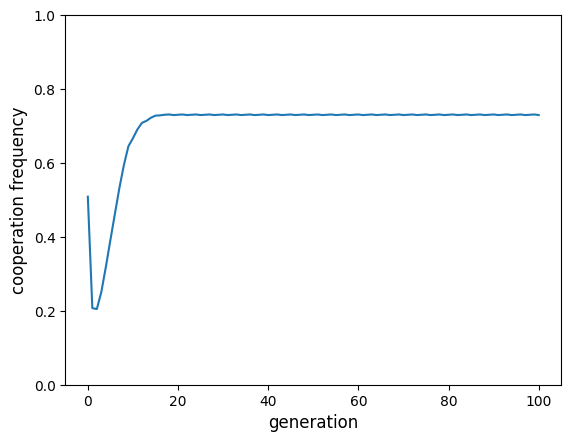

In [19]:
simulate(100)